<a href="https://colab.research.google.com/github/iMaIrsdyh/BigData26_B_2411533018_KarimahIrsyadiyah/blob/main/Praktikum1/BD_B_T01_2411533018_KarimahIrsyadiyah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS PRAKTIKUM 1 BIG DATA
**KARIMAH IRSYADIYAH**
***2411533018***

In [2]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       8.4Gi       2.1Mi       3.3Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.027s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.027s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Kode digunakan untuk mengetahui kondisi environment yang digunakan, seperti versi Python dan library, sistem operasi, jumlah CPU core, kapasitas RAM dan disk, serta versi Java.

In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0

    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1)
    })

    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

Kode membuat fungsi ukur() untuk mencatat waktu eksekusi dan perubahan penggunaan memori RSS dari setiap proses.

**J-4.1 — Download dataset Juli**

In [4]:
import os
import urllib.request

DIR_KERJA = "/content/data"
os.makedirs(DIR_KERJA, exist_ok=True)

URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    "yellow_tripdata_2023-07.parquet"
)

PATH = os.path.join(
    DIR_KERJA,
    "yellow_tripdata_2023-07.parquet"
)

if not os.path.exists(PATH):
    ukur(
        "unduh dataset Juli 2023",
        lambda: urllib.request.urlretrieve(URL, PATH)
    )

print(
    "Ukuran file:",
    round(os.path.getsize(PATH) / 1024**2, 1),
    "MB"
)

[unduh dataset Juli 2023] 0.54 s | RSS +1.8 MB
Ukuran file: 46.1 MB


Kode mengunduh dataset Yellow Taxi Juli 2023 dalam format Parquet dan menyimpannya pada folder kerja untuk digunakan pada proses berikutnya.

**J-4.2 — Cek metadata**

In [5]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata

print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 2,907,108
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


PyArrow digunakan untuk memeriksa metadata dataset tanpa membaca seluruh data, sehingga jumlah baris, kolom, row group, dan nama kolom dapat diketahui terlebih dahulu.

**J-5 — Baca kolom terpilih**

In [6]:
import pandas as pd

KOLUM = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

penuh = ukur(
    "baca semua kolom",
    lambda: pd.read_parquet(PATH)
)

print("Dimensi:", penuh.shape)
print(
    "Memori:",
    round(penuh.memory_usage(deep=True).sum() / 1024**2, 1),
    "MB"
)

del penuh

import gc
gc.collect()

df = ukur(
    "baca kolom terpilih",
    lambda: pd.read_parquet(PATH, columns=KOLUM)
)

print("Dimensi:", df.shape)
print(
    "Memori:",
    round(df.memory_usage(deep=True).sum() / 1024**2, 1),
    "MB"
)

df.head()

[baca semua kolom] 1.04 s | RSS +493.3 MB
Dimensi: (2907108, 19)
Memori: 502.5 MB
[baca kolom terpilih] 0.68 s | RSS +127.8 MB
Dimensi: (2907108, 8)
Memori: 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


membaca seluruh kolom dan kemudian hanya kolom yang diperlukan untuk analisis. Perbedaan waktu dan penggunaan memori dari kedua proses digunakan untuk melihat dampak pemilihan kolom terhadap efisiensi pembacaan data.

**J-5.2 — Cek penggunaan memori**

In [7]:
df.info(memory_usage="deep")

df.memory_usage(deep=True).sort_values(
    ascending=False
) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB


,0
tpep_pickup_datetime,22.179474
payment_type,22.179474
tpep_dropoff_datetime,22.179474
passenger_count,22.179474
trip_distance,22.179474
tip_amount,22.179474
fare_amount,22.179474
total_amount,22.179474
Index,0.000126


Kode digunakan untuk melihat tipe data dan penggunaan memori pada setiap kolom setelah hanya mengambil kolom yang diperlukan.

J-5.3 — Optimasi tipe data

In [8]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(
    df["passenger_count"],
    downcast="float"
)

df["payment_type"] = (
    df["payment_type"]
    .astype("int8")
    .astype("category")
)

for kol in [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]:
    df[kol] = pd.to_numeric(
        df[kol],
        downcast="float"
    )

sesudah = df.memory_usage(deep=True).sum() / 1024**2

print(
    f"{sebelum:.1f} MB -> {sesudah:.1f} MB "
    f"(hemat {100*(1-sesudah/sebelum):.1f}%)"
)

df.dtypes

177.4 MB -> 113.7 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Tipe data beberapa kolom dioptimalkan menggunakan downcast, sedangkan payment_type diubah menjadi category. Hasil sebelum dan sesudah dibandingkan untuk mengetahui penghematan penggunaan memori.

**J-6 — Cek kualitas data**

**J-6.1 — Cek durasi, missing value, dan anomali**

In [9]:
df["durasi_menit"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(
    df[
        ["trip_distance", "durasi_menit", "total_amount"]
    ].describe()
)

print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum()
}

for k, v in anomali.items():
    print(
        f"{k:22s}: {v:,} baris "
        f"({100*v/len(df):.2f}%)"
    )

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


igunakan untuk melihat statistik dasar, nilai kosong, dan data yang dianggap tidak wajar berdasarkan jarak perjalanan, durasi perjalanan, dan total tarif.

**J-6.2 — Membersihkan data**

In [10]:
layak = (
    (df["trip_distance"] > 0) &
    (df["trip_distance"] < 100) &
    (df["durasi_menit"].between(1, 180)) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()

print("Sebelum :", f"{len(df):,}")
print("Sesudah :", f"{len(bersih):,}")
print("Dibuang :", f"{len(df) - len(bersih):,}")

Sebelum : 2,907,108
Sesudah : 2,817,657
Dibuang : 89,451


Data disaring berdasarkan batas jarak, durasi, dan total tarif agar analisis hanya menggunakan perjalanan yang memenuhi kriteria. Jumlah data sebelum dan sesudah penyaringan dibandingkan untuk melihat banyaknya data yang dibuang.

**Lanjut J-7 — CSV dan chunking**

In [11]:
CSV = os.path.join(
    DIR_KERJA,
    "trips_juli.csv"
)

ukur(
    "tulis CSV",
    lambda: bersih.to_csv(CSV, index=False)
)

print(
    "Parquet:",
    round(os.path.getsize(PATH) / 1024**2, 1),
    "MB"
)

print(
    "CSV    :",
    round(os.path.getsize(CSV) / 1024**2, 1),
    "MB"
)


def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=[
            "tpep_pickup_datetime",
            "total_amount"
        ],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()

        for jam, sub in chunk.groupby(
            chunk["tpep_pickup_datetime"].dt.hour
        ):
            n, nilai = per_jam.get(jam, (0, 0.0))

            per_jam[jam] = (
                n + len(sub),
                nilai + sub["total_amount"].sum()
            )

    return jumlah_baris, total_nilai, per_jam


baris, total, per_jam_chunk = ukur(
    "agregasi chunking",
    lambda: agregasi_bertahap(CSV)
)

print(
    f"Baris={baris:,} | "
    f"rata-rata total_amount={total/baris:.2f}"
)

[tulis CSV] 37.42 s | RSS +5.2 MB
Parquet: 46.1 MB
CSV    : 213.6 MB
[agregasi chunking] 3.98 s | RSS +29.7 MB
Baris=2,817,657 | rata-rata total_amount=29.04


Data bersih disimpan dalam format CSV, kemudian dibaca kembali secara bertahap menggunakan chunking untuk menghitung jumlah perjalanan dan total tarif berdasarkan jam. Ukuran file dan penggunaan memori dicatat untuk membandingkan efisiensi penyimpanan dan pemrosesan data.

**J-8.1 — Menjalankan Spar**

In [12]:
!pip install -q pyspark==3.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 10.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [13]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark:", spark.version)

Spark: 3.5.1


Spark digunakan untuk memproses dataset dengan konfigurasi lokal dan pembagian shuffle sebanyak 8 partisi. Versi Spark ditampilkan untuk memastikan environment yang digunakan.

**J-8.2 — Baca Parquet, cleaning, dan agregasi**

In [14]:
sdf = spark.read.parquet(PATH)

sdf.printSchema()

print(
    "Jumlah baris:",
    ukur(
        "spark count",
        lambda: sdf.count()
    )
)

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp("tpep_dropoff_datetime")
            - F.unix_timestamp("tpep_pickup_datetime")
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100)
    )
    .filter(
        (F.col("durasi_menit") > 1) &
        (F.col("durasi_menit") <= 180)
    )
    .filter(
        F.col("total_amount") > 0
    )
)

hasil_spark = (
    sdf_bersih
    .withColumn(
        "jam",
        F.hour("tpep_pickup_datetime")
    )
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(
            F.avg("trip_distance"), 2
        ).alias("rata_jarak"),
        F.round(
            F.avg("total_amount"), 2
        ).alias("rata_tarif")
    )
    .orderBy("jam")
)

ukur(
    "spark agregasi",
    lambda: hasil_spark.show(
        24,
        truncate=False
    )
)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 4.91 s | RSS +0.0 MB
Jumlah baris: 2907108
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif

Dataset Parquet dibaca menggunakan Spark, kemudian dilakukan penyaringan berdasarkan kriteria kualitas data yang sama dengan proses pandas. Data yang sudah bersih dikelompokkan berdasarkan jam penjemputan untuk menghitung jumlah perjalanan, rata-rata jarak, dan rata-rata tarif.

**J-8.3 — Spark SQL**

In [15]:
sdf.createOrReplaceTempView("trips")

spark.sql("""
    SELECT
        payment_type,
        COUNT(*) AS jumlah,
        ROUND(AVG(total_amount), 2) AS rata_tarif,
        ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2227582|     30.03|    4.37|
|           2| 534101|     24.78|     0.0|
|           0|  85086|     30.52|     3.2|
|           4|  40641|      2.45|    0.06|
|           3|  19698|     10.83|    0.01|
+------------+-------+----------+--------+



dibuat sebagai temporary view agar dapat dianalisis menggunakan Spark SQL. Agregasi digunakan untuk melihat jumlah perjalanan, rata-rata tarif, dan rata-rata tip berdasarkan jenis pembayaran.

**J-8.4 — Lihat physical plan**

In [16]:
hasil_spark.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=190]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=187]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(Etc/UTC)) AS jam#84]
                  +- Filter ((((((isnotnull(trip_distance#4) AND isnotnull(total_amount#16)) AND (trip_distance#4 > 0.0)) AND (trip_distance#4 < 100.0)) AND ((cast((unix_timestamp(tpep_dropoff_datetime#2, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), false) - unix_timestamp(tpep_pickup_datetime#1, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), false)) as double) / 60.0) > 1.0)) AND ((c

explain() digunakan untuk melihat physical plan yang digunakan Spark dalam menjalankan proses agregasi, termasuk pembacaan Parquet, proses pengelompokan, dan pengurutan data.

**J-9 — Agregasi per jam**

In [17]:
import os
import pandas as pd

DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum01"
os.makedirs(DIR_SIMPAN, exist_ok=True)

bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (
    bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

agregasi.to_csv(
    f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv",
    index=False
)

agregasi.to_parquet(
    f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet",
    index=False
)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja_juli.csv",
    index=False
)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


Data yang sudah dibersihkan dikelompokkan berdasarkan jam penjemputan untuk menghitung jumlah perjalanan, rata-rata jarak, rata-rata durasi, rata-rata tarif, dan median tarif. Hasil agregasi kemudian disimpan dalam format CSV dan Parquet, sedangkan catatan waktu dan penggunaan memori disimpan dalam file CSV.

**J-10 — Grafik distribusi perjalanan per jam**

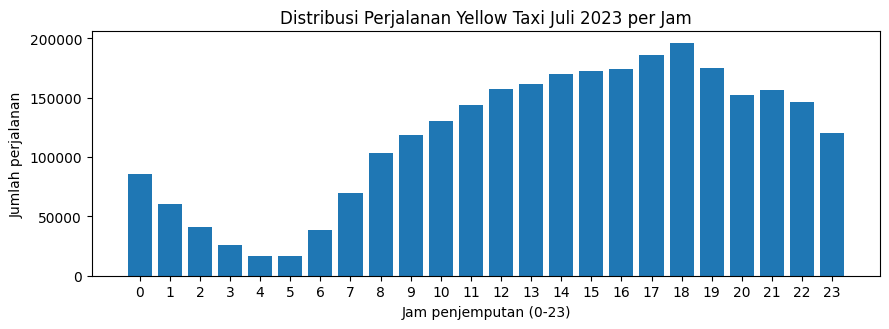

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))

ax.bar(
    agregasi["jam"],
    agregasi["jumlah_perjalanan"]
)

ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title(
    "Distribusi Perjalanan Yellow Taxi Juli 2023 per Jam"
)

ax.set_xticks(range(0, 24))

fig.tight_layout()

fig.savefig(
    f"{DIR_SIMPAN}/distribusi_per_jam_juli.png",
    dpi=150
)

plt.show()

Grafik batang digunakan untuk melihat distribusi jumlah perjalanan Yellow Taxi pada setiap jam penjemputan. Grafik disimpan dalam format PNG agar dapat digunakan sebagai hasil visualisasi pada laporan.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os

DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


**Q2.1 — Tabel perbandingan**

In [19]:
import os

DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

print("Isi folder Praktikum1:")
for nama in os.listdir(DIR_SIMPAN):
    print(nama)

Isi folder Praktikum1:
agregasi_per_jam.csv
agregasi_per_jam.parquet
pengukuran_kinerja.csv
distribusi_per_jam.png


In [20]:
import pandas as pd

# Hasil Januari 2023 dari praktikum sebelumnya
JAN_PATH = "/content/drive/MyDrive/BigData/Praktikum1/agregasi_per_jam.csv"

jan = pd.read_csv(JAN_PATH)

# Hasil Juli sudah tersimpan pada variabel agregasi
juli = agregasi.copy()

perbandingan = pd.DataFrame({
    "jam": jan["jam"],
    "januari_2023": jan["jumlah_perjalanan"],
    "juli_2023": juli["jumlah_perjalanan"]
})

perbandingan["selisih"] = (
    perbandingan["juli_2023"] -
    perbandingan["januari_2023"]
)

perbandingan["perubahan_persen"] = (
    perbandingan["selisih"] /
    perbandingan["januari_2023"] * 100
).round(2)

perbandingan

,jam,januari_2023,juli_2023,selisih,perubahan_persen
0,0,82289,85987,3698,4.49
1,1,57766,59980,2214,3.83
2,2,40445,40812,367,0.91
3,3,26146,26000,-146,-0.56
4,4,16618,16637,19,0.11
5,5,16940,16913,-27,-0.16
6,6,42300,38422,-3878,-9.17
7,7,84569,69358,-15211,-17.99
8,8,114064,103647,-10417,-9.13
9,9,127988,118788,-9200,-7.19


Hasil agregasi per jam dari Januari dan Juli digabungkan berdasarkan jam penjemputan. Tabel menampilkan jumlah perjalanan pada kedua bulan, selisih jumlah perjalanan, dan persentase perubahannya untuk melihat perbedaan pola perjalanan.

**Q2.2 — Grafik perbandingan**

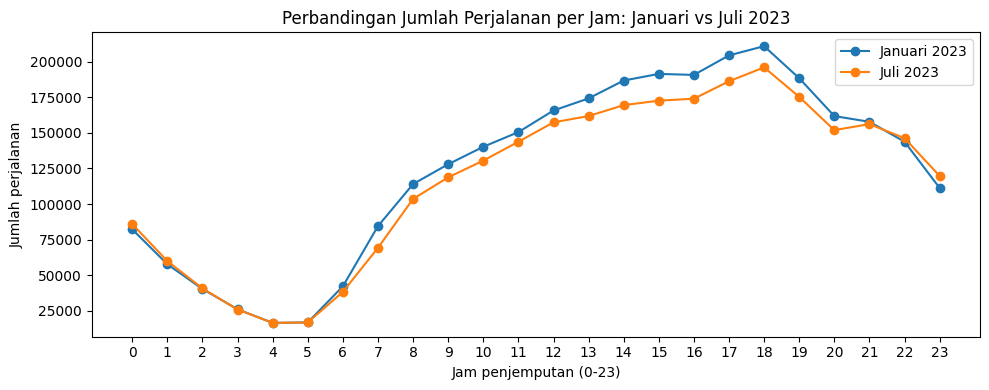

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    perbandingan["jam"],
    perbandingan["januari_2023"],
    marker="o",
    label="Januari 2023"
)

ax.plot(
    perbandingan["jam"],
    perbandingan["juli_2023"],
    marker="o",
    label="Juli 2023"
)

ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title(
    "Perbandingan Jumlah Perjalanan per Jam: Januari vs Juli 2023"
)

ax.set_xticks(range(0, 24))
ax.legend()

fig.tight_layout()

fig.savefig(
    f"{DIR_SIMPAN}/perbandingan_januari_juli.png",
    dpi=150
)

plt.show()

Grafik garis digunakan untuk membandingkan pola jumlah perjalanan pada setiap jam antara Januari dan Juli 2023. Bentuk garis memudahkan perubahan pola berdasarkan waktu terlihat secara langsung.

**Q2.3 — Simpan tabel**

In [22]:
perbandingan.to_csv(
    f"{DIR_SIMPAN}/perbandingan_januari_juli.csv",
    index=False
)

print("Tabel dan grafik perbandingan berhasil disimpan.")

Tabel dan grafik perbandingan berhasil disimpan.


**Q3.1 — Buat pengukuran_kinerja.csv**

In [23]:
# Simpan pengukuran kinerja dengan nama sesuai instruksi tugas
KINERJA_PATH = f"{DIR_SIMPAN}/pengukuran_kinerja.csv"

pd.DataFrame(catatan).to_csv(
    KINERJA_PATH,
    index=False
)

print("File kinerja:", KINERJA_PATH)
pd.DataFrame(catatan)

File kinerja: /content/drive/MyDrive/BigData/Praktikum1/pengukuran_kinerja.csv


,langkah,detik,delta_rss_mb
0,unduh dataset Juli 2023,0.54,1.8
1,baca semua kolom,1.04,493.3
2,baca kolom terpilih,0.68,127.8
3,tulis CSV,37.42,5.2
4,agregasi chunking,3.98,29.7
5,spark count,4.91,0.0
6,spark agregasi,7.22,0.0


**Q3.2 — Pembahasan**

### Pembahasan

Berdasarkan hasil pengukuran kinerja, langkah yang paling mahal dari sisi waktu adalah penulisan data ke CSV. Pada eksekusi Juli 2023, proses `tulis CSV` membutuhkan waktu **45,10 detik**, sedangkan proses `agregasi chunking` membutuhkan waktu **6,37 detik**. Penulisan CSV menjadi proses yang paling lama karena seluruh data bersih sebanyak **2.817.657 baris** harus dikonversi dan ditulis ke format teks.

Perubahan yang diusulkan adalah mempertahankan **Parquet sebagai format utama untuk penyimpanan dan pemrosesan data**, sehingga konversi seluruh data ke CSV tidak perlu dilakukan ketika tidak dibutuhkan. Hasil eksekusi juga menunjukkan ukuran CSV sebesar **213,6 MB**, sedangkan Parquet hanya **46,1 MB**.

Dengan demikian, penggunaan Parquet untuk proses lanjutan dapat mengurangi kebutuhan penyimpanan dan menghindari proses konversi CSV yang membutuhkan waktu cukup besar.

**Q4 — Refleksi Teori 5V**

Dataset Yellow Taxi Juli 2023 memiliki 2.907.108 baris dan 19 kolom dengan ukuran file Parquet sebesar 46,1 MB. Berdasarkan hasil eksekusi, dimensi yang paling mendekati karakteristik Big Data adalah **Volume**, karena jumlah datanya mencapai lebih dari 2,9 juta baris. Namun, ukuran file tersebut masih relatif kecil untuk ukuran pengolahan Big Data sehingga volumenya belum dapat dikatakan sangat besar.

Pada dimensi **Velocity**, dataset tidak benar-benar besar karena data yang digunakan merupakan data bulanan yang sudah tersimpan dalam file Parquet. Tidak terdapat proses streaming atau data yang masuk secara real-time. Pemrosesan dilakukan setelah seluruh dataset tersedia.

Pada dimensi **Variety**, dataset juga tidak terlalu besar. Data terdiri dari 19 kolom yang berbentuk data terstruktur, seperti waktu, jarak, jumlah penumpang, tipe pembayaran, dan nilai tarif. Dataset menggunakan satu format utama, yaitu Parquet, sehingga variasi jenis datanya relatif rendah.

Pada dimensi **Veracity**, terdapat masalah kualitas data yang terlihat dari hasil pemeriksaan. Sebanyak 85.086 baris memiliki nilai kosong pada `passenger_count` atau sekitar 2,93%. Selain itu, terdapat data dengan jarak, durasi, dan total tarif yang tidak memenuhi kriteria. Setelah proses cleaning, sebanyak 89.451 dari 2.907.108 baris dibuang atau sekitar 3,08% dari data awal. Hal ini menunjukkan bahwa kualitas data perlu diperiksa sebelum digunakan untuk analisis.

Pada dimensi **Value**, dataset memiliki nilai untuk analisis pola perjalanan. Hasil agregasi dapat menunjukkan jumlah perjalanan berdasarkan jam, rata-rata jarak, durasi, dan tarif. Namun, nilai bisnis atau nilai ekonominya tidak dapat ditentukan hanya dari pengukuran eksekusi notebook.

Berdasarkan kelima dimensi tersebut, **Volume merupakan dimensi yang paling terlihat**, sedangkan Velocity dan Variety belum menunjukkan karakteristik Big Data yang kuat. Veracity justru menunjukkan adanya kebutuhan untuk melakukan pembersihan data, sedangkan Value terlihat dari kemampuan dataset untuk menghasilkan informasi melalui proses analisis.

**Q5 — Reproducibility**

Notebook diuji dengan menjalankan kembali seluruh sel dari awal menggunakan runtime yang bersih melalui **Runtime → Restart and run all**. Pengujian dilakukan untuk memastikan seluruh library, variabel, dataset, folder penyimpanan, proses Spark, dan hasil analisis dapat dibuat kembali tanpa intervensi manual.

Notebook dinyatakan reproducible apabila seluruh sel dapat dijalankan dari awal sampai akhir tanpa error.